In [ ]:
!conda list 

# Database Processing for fragment library

In [2]:
from openbabel import pybel
from tqdm.notebook import tqdm

inputfile = "CaptFroggy.sdf"
outputfile = "newCaptFroggy.sdf"

written_count = 0
skipped_count = 0

# Count molecules first for tqdm total
total_mols = sum(1 for _ in pybel.readfile("sdf", inputfile))

out = pybel.Outputfile("sdf", outputfile, overwrite=True)

for i, mol in enumerate(tqdm(pybel.readfile("sdf", inputfile), total=total_mols, desc="Converting", unit="mol")):
    try:
        # Add hydrogens and generate 3D coordinates
        mol.addh()
        mol.make3D()  # This is the supported way!
        mol.data.clear()
        mol.data["SMILES"] = mol.write("smi").split()
        mol.data["InChIKey"] = mol.write("inchikey").split()
        mol.data["MolecularWeight"] = str(round(mol.molwt, 4))
        mol.data["LogP"] = str(mol.calcdesc(["logP"])["logP"])
        mol.data["MolecularID"] = f"q{i+1:05d}"

        out.write(mol)
        written_count += 1
    except Exception as e:
        skipped_count += 1
        tqdm.write(f"Skipped molecule {i+1}: {str(e)}")

out.close()
print(f"Done. Total processed: {written_count} molecules written, {skipped_count} skipped.")


Converting:   0%|          | 0/3188 [00:00<?, ?mol/s]

*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule (Frag00005)
  with Atom Ids as follows: 5
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule (Frag00008)
  with Atom Ids as follows: 3
*** Open Babel Warning  in InChI code
  Frag00008 :Ambiguous stereo: center(s)
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule (Frag00009)
  with Atom Ids as follows: 3
*** Open Babel Warning  in InChI code
  Frag00010 :Ambiguous stereo: center(s)
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule (Frag00018)
  with Atom Ids as follows: 3
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule (Frag00019)
  with Atom Ids as follows: 3
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule (Frag00020)
  with Atom Id

Done. Total processed: 3188 molecules written, 0 skipped.


*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule (Frag03334)
  with Atom Ids as follows: 10
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule (Frag03335)
  with Atom Ids as follows: 9
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule (Frag03336)
  with Atom Ids as follows: 10


In [3]:
from rdkit import Chem
from tqdm import tqdm

# Filenames
db1 = 'RO3.sdf'
db2 = 'newCaptFroggy.sdf'
merged = 'combinedSeeds.sdf'

# Helper: RDKit SDFReader yields molecule objects
def read_sdf(filename):
    suppl = Chem.SDMolSupplier(filename, sanitize=False, removeHs=False)
    return [mol for mol in suppl if mol is not None]

# Read molecules
mols1 = read_sdf(db1)
mols2 = read_sdf(db2)
all_mols = mols1 + mols2

# Write to merged.sdf with unique MolecularID
writer = Chem.SDWriter(merged)
for idx, mol in enumerate(tqdm(all_mols, desc="Writing merged SDF")):
    # Update MolecularID to be sequential
    mol.SetProp("MolecularID", f"q{idx+1:05d}")
    writer.write(mol)
writer.close()


Writing merged SDF:  40%|██████▍         | 1852/4643 [00:00<00:00, 18512.51it/s][22:35:35] Failed to find a good bond to set as UP or DOWN for an atropisomer - atoms are: 9 11
[22:35:35] Failed to find a good bond to set as UP or DOWN for an atropisomer - atoms are: 9 11
[22:35:35] Failed to find a good bond to set as UP or DOWN for an atropisomer - atoms are: 11 10
[22:35:35] Failed to find a good bond to set as UP or DOWN for an atropisomer - atoms are: 11 10
[22:35:35] Failed to find a good bond to set as UP or DOWN for an atropisomer - atoms are: 10 12
[22:35:35] Failed to find a good bond to set as UP or DOWN for an atropisomer - atoms are: 22 21
Writing merged SDF: 100%|████████████████| 4643/4643 [00:00<00:00, 13527.65it/s]


In [4]:
from rdkit import Chem

sdf_file = "combinedSeeds.sdf"

mols = Chem.SDMolSupplier(sdf_file, sanitize=False)
fields = set()
for mol in mols:
    if mol is None:
        continue
    fields.update(mol.GetPropNames())

print("Unique SDF field headers:")
for f in sorted(fields):
    print(f)


Unique SDF field headers:
InChIKey
LogP
MolecularID
MolecularWeight
SMILES


In [7]:
from rdkit import Chem

sdf_file = "concatenatedSeeds.sdf"
supplier = Chem.SDMolSupplier(sdf_file, sanitize=False)

count = sum(1 for mol in supplier if mol is not None)
print(f"Number of entries in {sdf_file}: {count}")


[23:09:39] ERROR: Counts line too short: '' on line4
[23:09:39] ERROR: moving to the beginning of the next molecule
[23:09:39] ERROR: Counts line too short: '' on line44
[23:09:39] ERROR: moving to the beginning of the next molecule
[23:09:39] ERROR: Counts line too short: '' on line104
[23:09:39] ERROR: moving to the beginning of the next molecule
[23:09:39] ERROR: Counts line too short: '' on line151
[23:09:39] ERROR: moving to the beginning of the next molecule
[23:09:39] ERROR: Counts line too short: '' on line198
[23:09:39] ERROR: moving to the beginning of the next molecule
[23:09:39] ERROR: Counts line too short: '' on line275
[23:09:39] ERROR: moving to the beginning of the next molecule
[23:09:39] ERROR: Counts line too short: '' on line343
[23:09:39] ERROR: moving to the beginning of the next molecule
[23:09:39] ERROR: Counts line too short: '' on line451
[23:09:39] ERROR: moving to the beginning of the next molecule
[23:09:39] ERROR: Counts line too short: '' on line559
[23:

Number of entries in concatenatedSeeds.sdf: 3188


In [5]:
from openbabel import pybel
from tqdm.notebook import tqdm

inputfile = "RO3.sdf"
outputfile = "newRO3.sdf"

written_count = 0
skipped_count = 0

# Count molecules for tqdm total
total_mols = sum(1 for _ in pybel.readfile("sdf", inputfile))

with open(outputfile, "w") as fout:
    for i, mol in enumerate(tqdm(pybel.readfile("sdf", inputfile), total=total_mols, desc="Converting", unit="mol")):
        try:
            mol.addh()
            mol.make3D()
            mol.data.clear()
            mol.data["SMILES"] = mol.write("smi").split()
            mol.data["InChIKey"] = mol.write("inchikey").split()
            mol.data["MolecularWeight"] = str(round(mol.molwt, 4))
            mol.data["LogP"] = str(mol.calcdesc(["logP"])["logP"])
            molid = f"Mol{i+1:05d}"
            mol.data["MolecularID"] = molid

            # Write the custom label as the first line
            fout.write(f"{molid}\n")

            # Write the SDF block (will add $$$$ automatically)
            fout.write(mol.write("sdf"))
            written_count += 1
        except Exception as e:
            skipped_count += 1
            tqdm.write(f"Skipped molecule {i+1}: {str(e)}")

print(f"Done. Total processed: {written_count} molecules written, {skipped_count} skipped.")


Converting:   0%|          | 0/1455 [00:00<?, ?mol/s]

*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 3 stereocenter(s) in this molecule ()
  with Atom Ids as follows: 6 9 10
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 2 stereocenter(s) in this molecule ()
  with Atom Ids as follows: 7 10
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule ()
  with Atom Ids as follows: 8
*** Open Babel Warning  in InChI code
  #1 :Proton(s) added/removed
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule ()
  with Atom Ids as follows: 6
*** Open Babel Warning  in InChI code
  #1 :Ambiguous stereo: center(s)
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 2 stereocenter(s) in this molecule ()
  with Atom Ids as follows: 4 6
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 2 stereocenter(s) in this molecule ()
  with Atom Ids as follows: 8 10
*** Open Babel Warning  in CorrectStereoAto

Done. Total processed: 1455 molecules written, 0 skipped.


In [6]:
# Concatenate RO3.sdf and froggy.sdf into one SDF file for screening in PyRx

ro3_path = "newRO3.sdf"      # Path to processed RO3 SDF file
froggy_path = "newCaptFroggy.sdf" # Path to processed froggy SDF file
output_path = "concatenatedSeeds.sdf"

with open(ro3_path, 'r') as ro3, open(froggy_path, 'r') as froggy, open(output_path, 'w') as out:
    # Write RO3 entries
    for line in ro3:
        out.write(line)
    # Write froggy entries
    for line in froggy:
        out.write(line)

print(f"Concatenation complete. Output saved to {output_path}")


Concatenation complete. Output saved to concatenatedSeeds.sdf


In [8]:
# Replace with your concatenated database file path
sdf_file = "concatenatedSeeds.sdf"

with open(sdf_file, "r") as f:
    count = sum(1 for line in f if line.strip() == "$$$$")

print(f"Total number of entries: {count}")


Total number of entries: 4643


In [4]:
!obabel fixedSeeds.sdf -osdf -O checkedSeeds.sdf

*** Open Babel Warning  in ReadMolecule
Cannot read atom and bond count
Expected standard 6 character atom and bond count

0 molecules converted


In [3]:
input_file = "concatenatedSeeds.sdf"
output_file = "fixedSeeds.sdf"

with open(input_file, "r") as fin, open(output_file, "w") as fout:
    lines = fin.readlines()
    i = 0
    while i < len(lines):
        # Write first three header lines as-is
        fout.write(lines[i])   # Molecule name
        i += 1
        fout.write(lines[i])   # Program line
        i += 1
        fout.write(lines[i])   # Comment line
        i += 1

        # Attempt to fix counts line on the 4th line
        parts = lines[i].split()
        if len(parts) >= 2 and parts[0].isdigit() and parts[1].isdigit():
            # Rebuild counts line with proper spacing (columns 1–3 = atom, 4–6 = bond)
            new_counts_line = f"{int(parts[0]):>3}{int(parts[1]):>3}" + lines[i][6:]
            fout.write(new_counts_line)
        else:
            fout.write(lines[i])  # if not a standard counts line, just write as is
        i += 1

        # Write the rest of the molecule block until $$$$
        while i < len(lines) and lines[i].strip() != "$$$$":
            fout.write(lines[i])
            i += 1
        # Write molecule delimiter $$$$, if present
        if i < len(lines):
            fout.write(lines[i])
            i += 1


In [5]:
# Install RDKit if needed
from rdkit import Chem
import pandas as pd

# --------- User: Set the SDF filename here ---------
sdf_filename = 'concatenatedSeeds.sdf'  # <-- Replace with your file
# ---------------------------------------------------

# Read SDF file and extract SMILES and molecular ID
supplier = Chem.SDMolSupplier(sdf_filename)
data = []
for mol in supplier:
    if mol is not None:
        smiles = Chem.MolToSmiles(mol)
        # Default: try '_Name', or look for common ID fields
        mol_id = mol.GetProp('_Name') if mol.HasProp('_Name') else None
        if not mol_id:
            for key in mol.GetPropNames():
                if 'id' in key.lower():
                    mol_id = mol.GetProp(key)
                    break
        data.append({'mol_id': mol_id, 'smiles': smiles})

df = pd.DataFrame(data)

# Save as CSV file (columns: mol_id, smiles)
csv_file = 'mol_db.csv'
df.to_csv(csv_file, index=False)

# Save as SMILES database (.smi): SMILES<TAB>ID per line, as required by OpenBabel/PyRx
smi_file = 'mol_db.smi'
df[['smiles', 'mol_id']].to_csv(smi_file, sep='\t', header=False, index=False)

print(f"CSV saved to: {csv_file}")
print(f"SMILES saved to: {smi_file}")


[21:51:04] ERROR: Counts line too short: '' on line4
[21:51:04] ERROR: moving to the beginning of the next molecule
[21:51:04] ERROR: Counts line too short: '' on line44
[21:51:04] ERROR: moving to the beginning of the next molecule
[21:51:04] ERROR: Counts line too short: '' on line104
[21:51:04] ERROR: moving to the beginning of the next molecule
[21:51:04] ERROR: Counts line too short: '' on line151
[21:51:04] ERROR: moving to the beginning of the next molecule
[21:51:04] ERROR: Counts line too short: '' on line198
[21:51:04] ERROR: moving to the beginning of the next molecule
[21:51:04] ERROR: Counts line too short: '' on line275
[21:51:04] ERROR: moving to the beginning of the next molecule
[21:51:04] ERROR: Counts line too short: '' on line343
[21:51:04] ERROR: moving to the beginning of the next molecule
[21:51:04] ERROR: Counts line too short: '' on line451
[21:51:04] ERROR: moving to the beginning of the next molecule
[21:51:04] ERROR: Counts line too short: '' on line559
[21:

CSV saved to: mol_db.csv
SMILES saved to: mol_db.smi


In [6]:
import math

# --------- User: Set filenames here ---------
input_smi = 'mol_db.smi'  # <-- Replace with your SMILES file name
num_batches = 5
# --------------------------------------------

# Read all lines from the input .smi file
with open(input_smi, 'r') as f:
    lines = f.readlines()

total = len(lines)
batch_size = math.ceil(total / num_batches)

# Write batches to new files
for i in range(num_batches):
    start = i * batch_size
    end = min(start + batch_size, total)
    batch_lines = lines[start:end]
    batch_filename = f'seedlet{i+1}.smi'
    with open(batch_filename, 'w') as out:
        out.writelines(batch_lines)
    print(f'Batch {i+1}: {batch_filename} ({len(batch_lines)} SMILES)')


Batch 1: seedlet1.smi (638 SMILES)
Batch 2: seedlet2.smi (638 SMILES)
Batch 3: seedlet3.smi (638 SMILES)
Batch 4: seedlet4.smi (638 SMILES)
Batch 5: seedlet5.smi (636 SMILES)


In [7]:
import pandas as pd

# --------- User: Set your filename here ---------
smi_file = 'mol_db.smi'  # <-- Replace with your .smi file
# ------------------------------------------------

# Read SMILES file (assuming two columns: SMILES [col 0], ID [col 1], tab-separated)
df = pd.read_csv(smi_file, sep='\t', header=None, names=['smiles', 'mol_id'])

# Find duplicate mol_id entries
duplicates = df[df.duplicated('mol_id', keep=False)]

if not duplicates.empty:
    print("Duplicate molecule IDs found:")
    print(duplicates.sort_values('mol_id').to_string(index=False))
else:
    print("No duplicate molecule IDs found.")


No duplicate molecule IDs found.


# Molecular Descriptors for Chemical Space analysis


## For physico-chemical and topological indices
below is the actual script. to run it, use bash
python Molc_desc.py input.sdf output.csv

In [3]:
!python Molc_desc.py /home/nikka/VinaScreen/Combine4dock.sdf top10frags_molcDesc.csv

Processing molecules: 100%|███████████████████| 41/41 [00:00<00:00, 1761.70it/s]
CSV file successfully written to: top10frags_molcDesc.csv


### For more detailed chemical properties for diversity determination

In [2]:
!python Molc_desc.py CMNPD_1.0_3d.sdf cmnpd_detailedDesc.csv

Processing molecules: 100%|█████████████| 47451/47451 [00:43<00:00, 1084.10it/s]
CSV file successfully written to: cmnpd_detailedDesc.csv


### Calculates Murcko scaffolds and diversity analyses

In [6]:
!python Murcko.py /home/nikka/VinaScreen/Combine4dock.sdf --output_prefix frag

Extracting scaffolds: 100%|███████████████| 4643/4643 [00:00<00:00, 4841.18it/s]
Murcko scaffold dataframe written to frag_murcko_dataframe.csv
Scaffold frequency table written to frag_scaffold_frequency.csv
Scaffold distribution metrics written to frag_scaffold_metrics.csv


## For topological indices and fingerprints
below is the actual script. to run it, use bash
python Molc_indx.py input.sdf output.csv

In [4]:
!python Molc_indx.py /home/nikka/VinaScreen/Combine4dock.sdf Vinafrags_molcIndx.csv

Processing molecules: 100%|████████████████| 4643/4643 [00:08<00:00, 561.54it/s]
Saved output to Vinafrags_molcIndx.csv


## Dimensionality reduction with PCA and UMAP

/home/nikka/miniconda3/envs/deepFrog311/lib/python3.11/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['WienerIndex']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


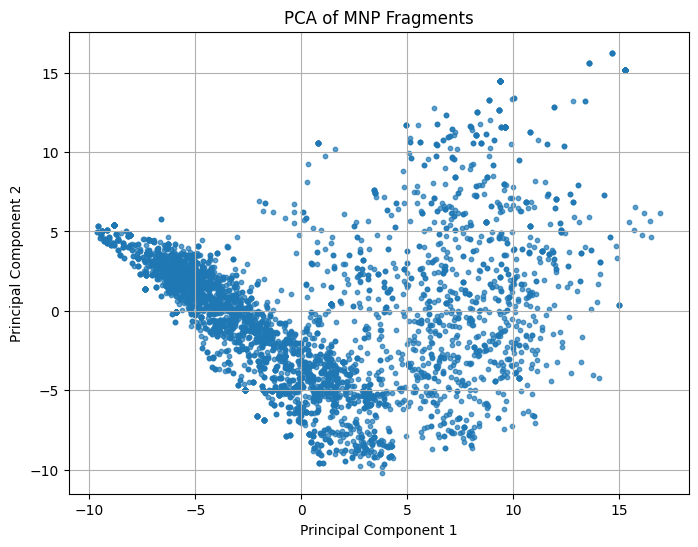

In [20]:
# PCA dimensionality reduction and plotting with NaN imputation
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# Load your two CSV files (update paths as needed)
df_physchem = pd.read_csv('Vinafrags_molcDesc.csv')   # e.g. MolID,SMILES,MolWt,LogP,TPSA, etc.
df_fingerprints = pd.read_csv('Vinafrags_molcIndx.csv') # e.g. MolID,SMILES,Wiener,MACCS_1,...,ECFP4_1,...

# Merge dataframes on molecule ID (adjust column name as appropriate)
df = pd.merge(df_physchem, df_fingerprints, on=['MolecularID', 'SMILES'])

# Use Physicochem only
#df = df_physchem

# Select descriptor columns for PCA
drop_cols = ['MolecularID', 'SMILES']
desc_cols = [col for col in df.columns if col not in drop_cols]
X = df[desc_cols]

# Impute missing values with the column mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Standardize features (important for PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Run PCA
n_components = 2
pca = PCA(n_components=n_components)
principal_comp = pca.fit_transform(X_scaled)

# Add results to dataframe for plotting/reference
df['PC1'] = principal_comp[:, 0]
df['PC2'] = principal_comp[:, 1]

# Chemical space scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df['PC1'], df['PC2'], s=10, alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNP Fragments') #change graph title
plt.grid(True)
#plt.savefig('pca.png', dpi=400, bbox_inches='tight') #change filename
plt.show()
#(Optional) Export result dataframe for further labeling or interactive use; change filename
df.to_csv('vinafrags_pca_out.csv', index=False)


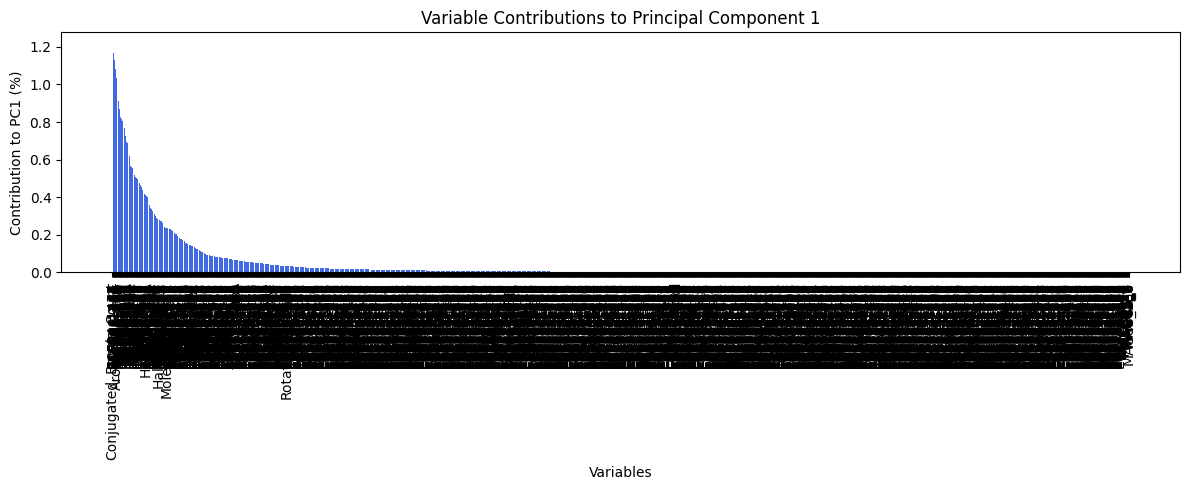

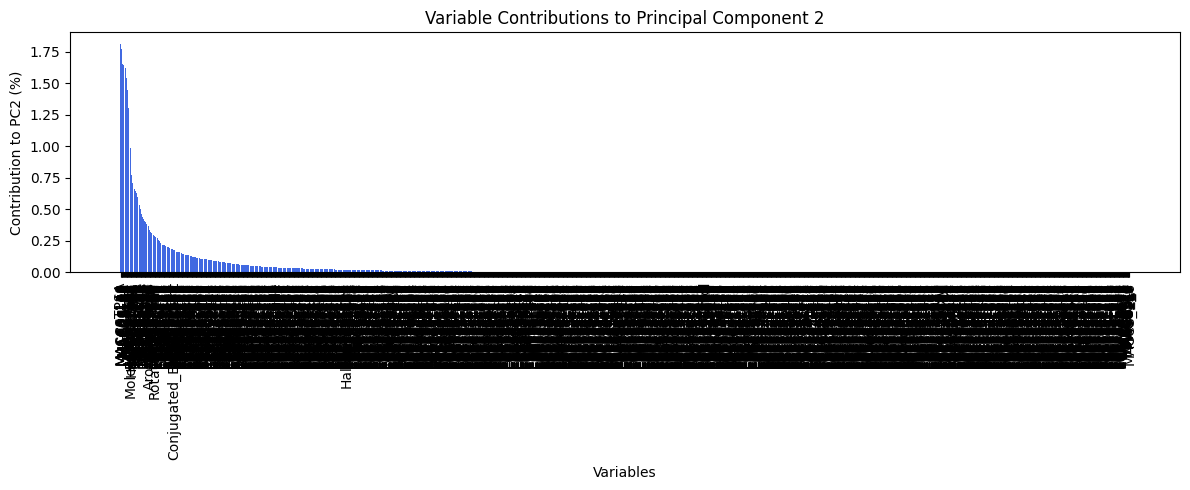

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# After your PCA fit, assuming 'pca' is your trained sklearn PCA object
# and 'desccols' is the list of feature names
loadings = pca.components_         # shape: (n_components, n_features)
feature_names = desc_cols           # list of variable names

num_components_to_plot = 2         # number of PCs to plot

for pc_num in range(num_components_to_plot):  # loop over PC1, PC2, etc.
    contrib = loadings[pc_num] ** 2
    contrib_percent = 100 * contrib / np.sum(contrib)
    sorted_idx = np.argsort(contrib_percent)[::-1]

    plt.figure(figsize=(12, 5))
    plt.bar(np.array(feature_names)[sorted_idx],
            contrib_percent[sorted_idx], color='royalblue')
    plt.xlabel('Variables')
    plt.ylabel(f'Contribution to PC{pc_num+1} (%)')
    plt.title(f'Variable Contributions to Principal Component {pc_num+1}')
    plt.xticks(rotation=90)
    plt.tight_layout()
    #plt.savefig(f'Physchem_var_contributions_PC{pc_num+1}.png', dpi=300)
    plt.show()
    # Create DataFrame for sorted results
    df_pc = pd.DataFrame({
        'Variable': np.array(feature_names)[sorted_idx],
        f'PC{pc_num+1}_Contribution (%)': contrib_percent[sorted_idx]
    })

# Save to CSV
df_pc.to_csv(f'CMNPD_var_contrib_PC{pc_num+1}.csv', index=False)





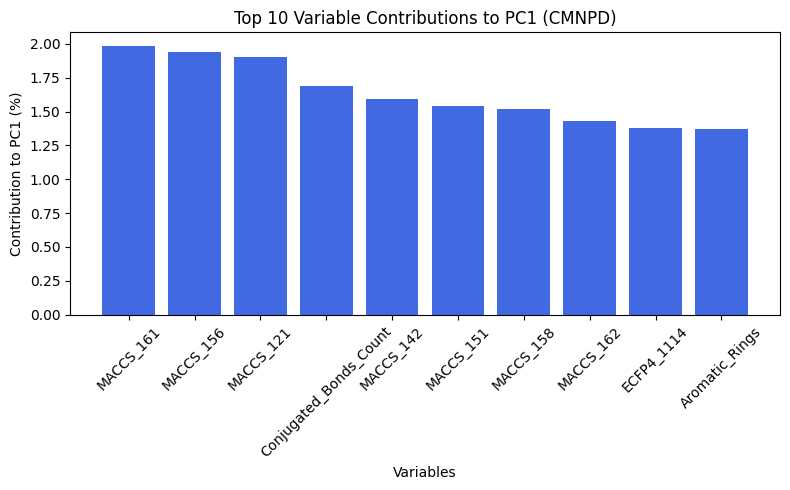

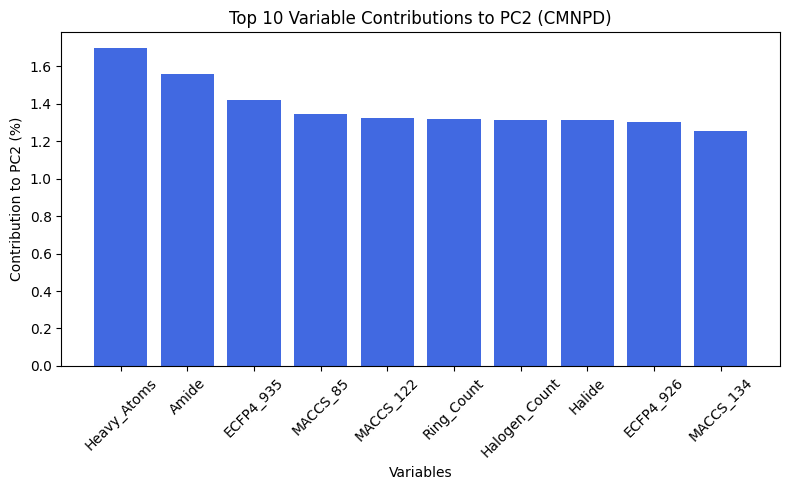

In [21]:
#top variables contribution to PCA
import numpy as np
import matplotlib.pyplot as plt

# After fitting PCA and having desccols (list of feature names)
loadings = pca.components_
feature_names = desc_cols

# User-defined number of top contributors to display
top_x = 10  # Change this number for your preference

num_components_to_plot = 2  # For first 2 PCs

for pc_num in range(num_components_to_plot):
    contrib = loadings[pc_num] ** 2
    contrib_percent = 100 * contrib / np.sum(contrib)
    sorted_idx = np.argsort(contrib_percent)[::-1]

    # Select only top X contributors
    top_features = np.array(feature_names)[sorted_idx][:top_x]
    top_contrib_percent = contrib_percent[sorted_idx][:top_x]

    plt.figure(figsize=(8, 5))
    plt.bar(top_features, top_contrib_percent, color='royalblue')
    plt.xlabel('Variables')
    plt.ylabel(f'Contribution to PC{pc_num+1} (%)')
    plt.title(f'Top {top_x} Variable Contributions to PC{pc_num+1} (CMNPD)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'Top{top_x}_Variable_Contributions_PC{pc_num+1}_(Fragments).png', dpi=300)
    plt.show()


In [22]:
Physchem = ['LogP', 'MolecularWeight', 'TPSA', 'Num_HBD', 'Num_HBA', 'Rotatable_Bonds', 'Conjugated_Bonds_Count', 'Ring_Count', 'Aromatic_Rings', 'Halogen_Count', 'Heavy_Atoms', 'Alcohol', 'Amine', 'Carboxyl', 'Carbonyl', 'Imine', 'Thiol', 'Sulfide', 'Halide', 'Amide'
           ]

In [28]:
print(set(feature_names) & set(Physchem))


{'Ring_Count', 'Sulfide', 'Carboxyl', 'Conjugated_Bonds_Count', 'LogP', 'Amide', 'Halogen_Count', 'Carbonyl', 'Alcohol', 'Num_HBA', 'Thiol', 'Amine', 'Aromatic_Rings', 'Rotatable_Bonds', 'Halide', 'Heavy_Atoms', 'Num_HBD', 'Imine', 'MolecularWeight', 'TPSA'}


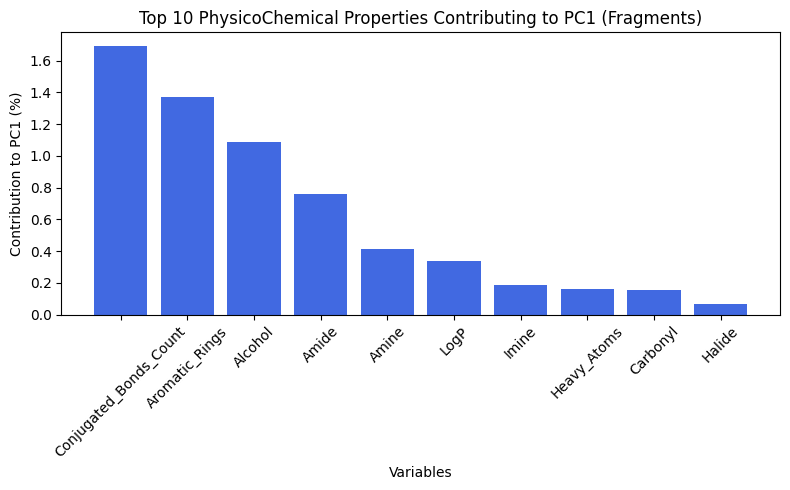

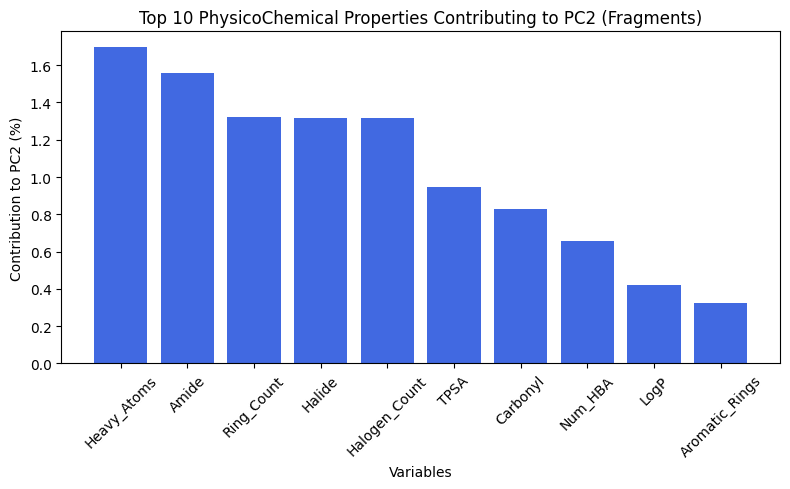

In [29]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = np.array([x.strip() for x in feature_names])
Physchem = [x.strip() for x in Physchem]

# User-defined columns to consider for top contributors
selected_cols = Physchem
selected_indices = []
missing_cols = []
for c in selected_cols:
    idx = np.where(feature_names == c)[0]
    if len(idx) > 0:
        selected_indices.append(idx[0])
    else:
        missing_cols.append(c)
if missing_cols:
    print("Warning: These columns are missing from desc_cols:", missing_cols)

# After fitting PCA and having desc_cols (list of all feature names)
loadings = pca.components_
feature_names = np.array(desc_cols)
selected_feature_names = feature_names[selected_indices]

top_x = 10  # Top X among selected columns
num_components_to_plot = 2  # For first 2 PCs

for pc_num in range(num_components_to_plot):
    contrib = loadings[pc_num] ** 2
    contrib_percent = 100 * contrib / np.sum(contrib)

    # Filter for selected columns
    selected_contrib_percent = contrib_percent[selected_indices]
    selected_feature_names = feature_names[selected_indices]

    # Sort among selected columns
    sorted_idx = np.argsort(selected_contrib_percent)[::-1]
    top_features = selected_feature_names[sorted_idx][:top_x]
    top_contrib_percent = selected_contrib_percent[sorted_idx][:top_x]

    plt.figure(figsize=(8, 5))
    plt.bar(top_features, top_contrib_percent, color='royalblue')
    plt.xlabel('Variables')
    plt.ylabel(f'Contribution to PC{pc_num+1} (%)')
    plt.title(f'Top {top_x} PhysicoChemical Properties Contributing to PC{pc_num+1} (Fragments)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'Top{top_x}_PhysicoChemical_vinafrags_{pc_num+1}.png', dpi=300)
    plt.show()


/home/nikka/miniconda3/envs/deepFrog311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


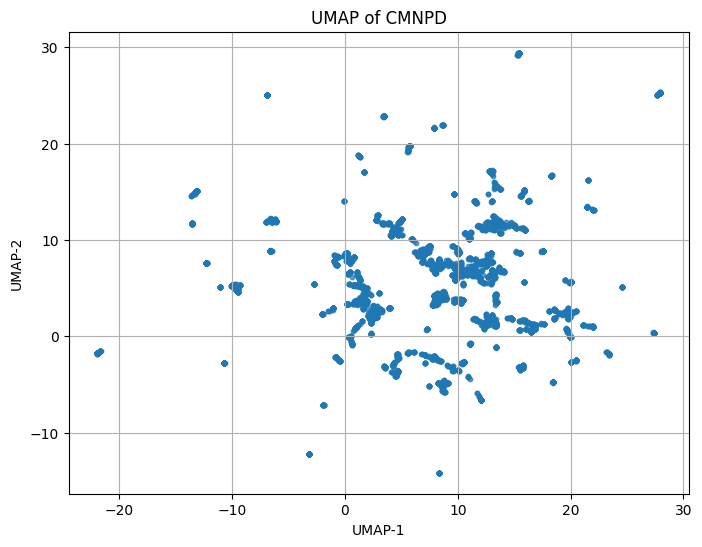

In [34]:
# Dimensionality reduction with UMAP and robust pre-processing
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import umap

# Load your two CSV files (edit the file names/paths as required)
df_physchem = pd.read_csv('Vinafrags_molcDesc.csv')     # e.g. MolID,SMILES,MolWt,LogP,TPSA,...
df_fingerprints = pd.read_csv('Vinafrags_molcIndx.csv') # e.g. MolID,SMILES,Wiener,MACCS_1,...,ECFP4_1,...

# Merge on molecule ID and SMILES
#df = pd.merge(df_physchem, df_fingerprints, on=['MolecularID', 'SMILES'])

#use only PhysChem
df = df_physchem

# Select descriptor columns for dimensionality reduction
drop_cols = ['MolecularID', 'SMILES']
desc_cols = [col for col in df.columns if col not in drop_cols]
X = df[desc_cols]

# Drop columns with all missing data
X = X.dropna(axis=1, how='all')

# Impute remaining missing values with column means
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Drop columns with zero variance
selector = VarianceThreshold(threshold=0.0)
X_sel = selector.fit_transform(X_imputed)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sel)

# Perform UMAP with higher n_neighbors to help sparse clusters
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, metric='euclidean', random_state=42)
umap_embedding = reducer.fit_transform(X_scaled)

# Add results to dataframe for plotting/reference
df['UMAP1'] = umap_embedding[:, 0]
df['UMAP2'] = umap_embedding[:, 1]

# Chemical space scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df['UMAP1'], df['UMAP2'], s=10, alpha=0.7)
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.title('UMAP of CMNPD')
plt.grid(True)
#plt.savefig('cmnpd_umap.png', dpi=400, bbox_inches='tight') #change filename
plt.show()

# (Optional) Save results for future analysis or interactive plotting
df.to_csv('vinafrags_umap_out.csv', index=False) #change filename


In [52]:
import pandas as pd
import numpy as np

# Load your CSV from preprocessing ('frag_physchem_umap_output.csv' from your UMAP workflow)
df = pd.read_csv('frag_umap_out.csv')

# Select only physicochemical descriptor columns
# list physchem

# Calculate absolute correlations between each variable and UMAP axes
correlations = pd.DataFrame({
    'Variable': physchem,
    'UMAP1_corr': [np.corrcoef(df[var], df['UMAP1'])[0, 1] for var in physchem],
    'UMAP2_corr': [np.corrcoef(df[var], df['UMAP2'])[0, 1] for var in physchem]
})

correlations['abs_UMAP1_corr'] = correlations['UMAP1_corr'].abs()
correlations['abs_UMAP2_corr'] = correlations['UMAP2_corr'].abs()

correlations.to_csv('cmnpd_var_contrib.csv', index=False)
# Top 10 for each axis
print("Top 10 contributors to UMAP1:")
print(correlations.nlargest(10, 'abs_UMAP1_corr')[['Variable','UMAP1_corr']])

print("\nTop 10 contributors to UMAP2:")
print(correlations.nlargest(10, 'abs_UMAP2_corr')[['Variable','UMAP2_corr']])


Top 10 contributors to UMAP1:
         Variable  UMAP1_corr
4         Num_HBD   -0.373293
14       Carboxyl   -0.330918
10  Halogen_Count   -0.293537
19         Halide   -0.293537
2           MolWt   -0.263761
3            TPSA   -0.260570
16          Imine   -0.226939
12        Alcohol   -0.200639
13          Amine   -0.141692
0            LogP    0.098185

Top 10 contributors to UMAP2:
                  Variable  UMAP2_corr
12                 Alcohol   -0.410641
2                    MolWt   -0.291467
4                  Num_HBD   -0.226677
13                   Amine    0.218737
20                   Amide    0.204818
11             Heavy_Atoms   -0.191101
0                     LogP   -0.182385
15                Carbonyl    0.164295
7   Conjugated_Bonds_Count    0.152005
16                   Imine    0.124803


In [35]:
# top physicochem variables only# Check for presence of physchem columns in df
present_cols = [var for var in Physchem if var in df.columns]
missing_cols = [var for var in Physchem if var not in df.columns]
if missing_cols:
    print("Warning: These columns are missing from DataFrame:", missing_cols)

# Calculate correlations for present columns only
correlations = pd.DataFrame({
    'Variable': present_cols,
    'UMAP1_corr': [np.corrcoef(df[var], df['UMAP1'])[0, 1] for var in present_cols],
    'UMAP2_corr': [np.corrcoef(df[var], df['UMAP2'])[0, 1] for var in present_cols]
})

correlations['abs_UMAP1_corr'] = correlations['UMAP1_corr'].abs()
correlations['abs_UMAP2_corr'] = correlations['UMAP2_corr'].abs()

correlations.to_csv('cmnpd_var_contrib.csv', index=False)
print("Top 10 contributors to UMAP1:")
print(correlations.nlargest(10, 'abs_UMAP1_corr')[['Variable','UMAP1_corr']])

print("\nTop 10 contributors to UMAP2:")
print(correlations.nlargest(10, 'abs_UMAP2_corr')[['Variable','UMAP2_corr']])

Top 10 contributors to UMAP1:
         Variable  UMAP1_corr
3         Num_HBD   -0.373293
13       Carboxyl   -0.330918
9   Halogen_Count   -0.293537
18         Halide   -0.293537
2            TPSA   -0.260570
15          Imine   -0.226939
11        Alcohol   -0.200639
12          Amine   -0.141692
0            LogP    0.098185
19          Amide   -0.072415

Top 10 contributors to UMAP2:
                  Variable  UMAP2_corr
11                 Alcohol   -0.410641
3                  Num_HBD   -0.226677
12                   Amine    0.218737
19                   Amide    0.204818
10             Heavy_Atoms   -0.191101
0                     LogP   -0.182385
14                Carbonyl    0.164295
6   Conjugated_Bonds_Count    0.152005
15                   Imine    0.124803
2                     TPSA   -0.095288


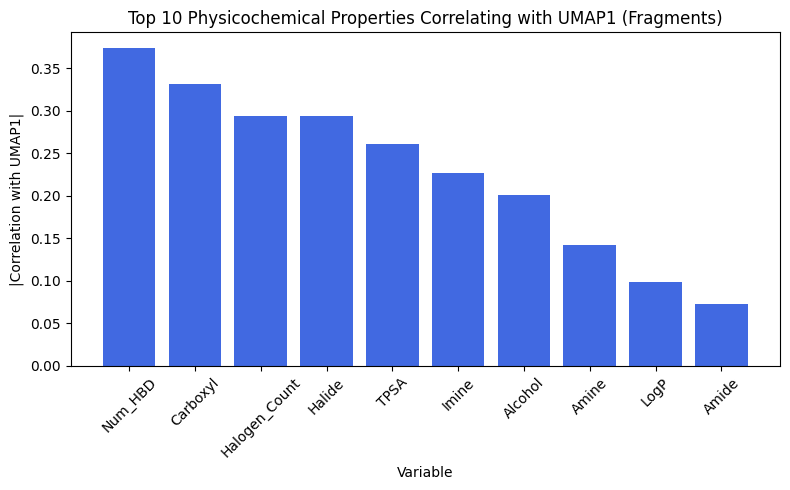

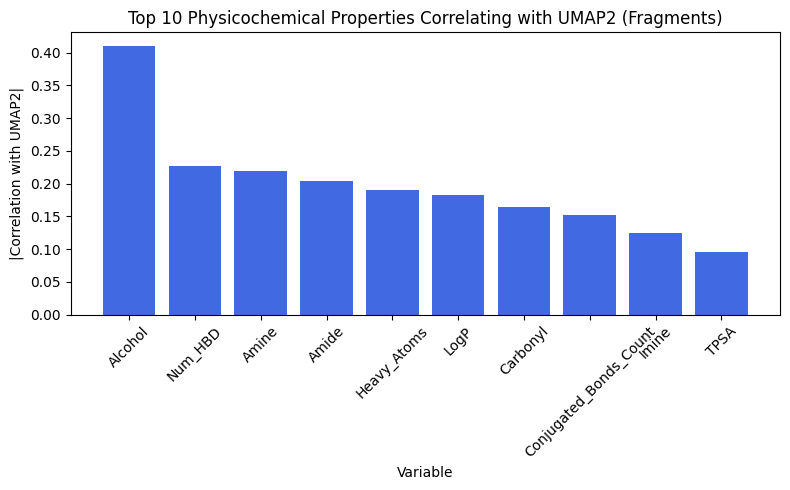

In [36]:
import matplotlib.pyplot as plt

# Assume 'correlations' DataFrame already exists from your workflow

for umap_axis, label in zip(['abs_UMAP1_corr', 'abs_UMAP2_corr'], ['UMAP1', 'UMAP2']):
    top10 = correlations.nlargest(10, umap_axis)
    plt.figure(figsize=(8,5))
    plt.bar(top10['Variable'], top10[umap_axis], color='royalblue')
    plt.xlabel('Variable')
    plt.ylabel(f'|Correlation with {label}|')
    plt.title(f'Top 10 Physicochemical Properties Correlating with {label} (Fragments)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'top10_physchem_{label}_corr_vinafrags.png', dpi=300)
    plt.show()


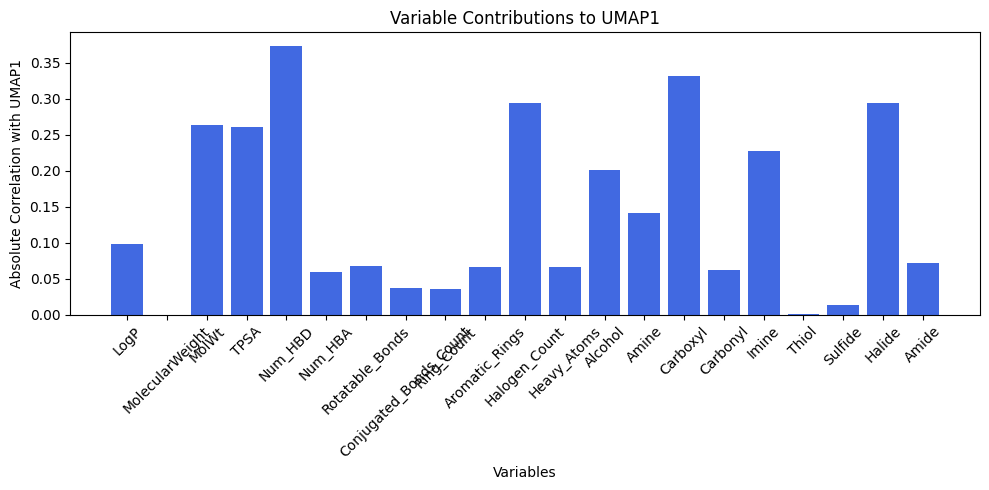

In [20]:
import matplotlib.pyplot as plt

# Bar graph of correlation magnitudes for Physchem variables (pick axis, e.g., UMAP1)
plt.figure(figsize=(10,5))
plt.bar(correlations['Variable'], correlations['abs_UMAP1_corr'], color='royalblue')
plt.xlabel('Variables')
plt.ylabel('Absolute Correlation with UMAP1')
plt.title('Variable Contributions to UMAP1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


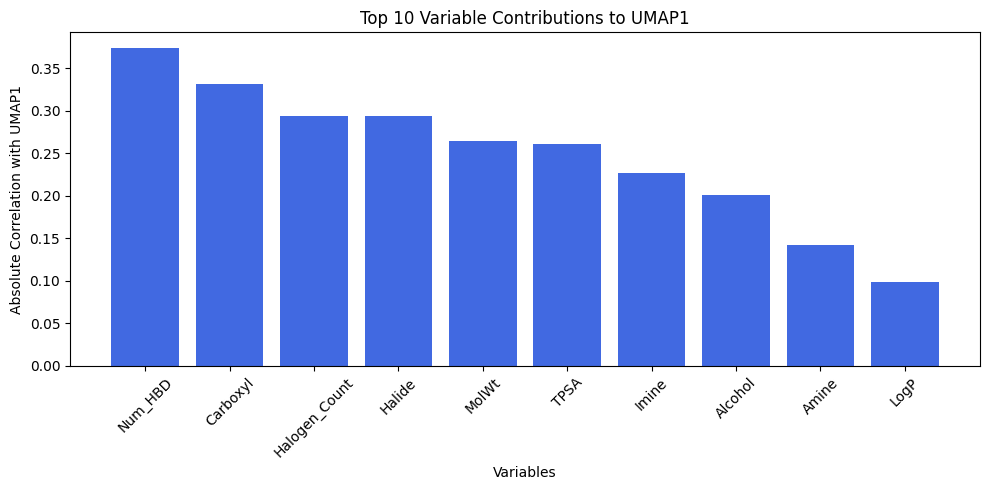

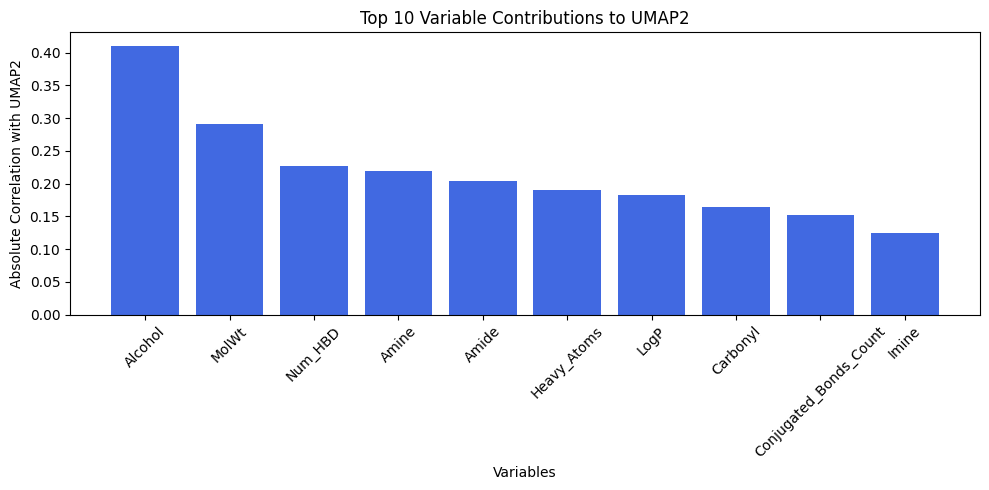

In [29]:
import matplotlib.pyplot as plt

# Sort and select top 10 contributors to UMAP1 by absolute value
top_x = correlations.nlargest(10, 'abs_UMAP1_corr')

plt.figure(figsize=(10,5))
plt.bar(top_x['Variable'], top_x['abs_UMAP1_corr'], color='royalblue')
plt.xlabel('Variables')
plt.ylabel('Absolute Correlation with UMAP1')
plt.title('Top 10 Variable Contributions to UMAP1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'Top10_PhysChem_var_UMAP1.png', dpi=300)
plt.show()

# Sort and select top 10 contributors to UMAP2 by absolute value
top_y = correlations.nlargest(10, 'abs_UMAP2_corr')

plt.figure(figsize=(10,5))
plt.bar(top_y['Variable'], top_y['abs_UMAP2_corr'], color='royalblue')
plt.xlabel('Variables')
plt.ylabel('Absolute Correlation with UMAP2')
plt.title('Top 10 Variable Contributions to UMAP2')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'Top10_PhysChem_var_UMAP2.png', dpi=300)
plt.show()



In [12]:
import pandas as pd
import numpy as np

# X_scaled: your standardized feature matrix (samples x variables)
# umap_embedding: your UMAP output (samples x 2)
# feature_names: list of variable names (e.g., desccols)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)
umap_df = pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'])

# Calculate correlations for each variable with each UMAP axis
correlations = {
    'Variable': feature_names,
    'UMAP1_corr': [np.corrcoef(X_scaled_df[feature], umap_df['UMAP1'])[0, 1] for feature in feature_names],
    'UMAP2_corr': [np.corrcoef(X_scaled_df[feature], umap_df['UMAP2'])[0, 1] for feature in feature_names]
}

corr_df = pd.DataFrame(correlations)
corr_df['abs_UMAP1_corr'] = np.abs(corr_df['UMAP1_corr'])
corr_df['abs_UMAP2_corr'] = np.abs(corr_df['UMAP2_corr'])

# Show the top 10 contributors for each axis
top_umap1 = corr_df.nlargest(10, 'abs_UMAP1_corr')
top_umap2 = corr_df.nlargest(10, 'abs_UMAP2_corr')

print("Top contributors to UMAP1:")
print(top_umap1[['Variable', 'UMAP1_corr']])

print("\nTop contributors to UMAP2:")
print(top_umap2[['Variable', 'UMAP2_corr']])


ValueError: Shape of passed values is (4643, 21), indices imply (4643, 2237)

In [13]:
import matplotlib.pyplot as plt

top_x = 10  # Change this to any desired number

# For UMAP1
top_umap1 = corr_df.nlargest(top_x, 'abs_UMAP1_corr')
plt.figure(figsize=(8, 5))
plt.bar(top_umap1['Variable'], top_umap1['abs_UMAP1_corr'], color='royalblue')
plt.xlabel('Variables')
plt.ylabel('Absolute Correlation with UMAP1')
plt.title(f'Top {top_x} Contributors to UMAP1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'Top{top_x}_Contributors_UMAP1.png', dpi=300)
plt.show()

# For UMAP2
top_umap2 = corr_df.nlargest(top_x, 'abs_UMAP2_corr')
plt.figure(figsize=(8, 5))
plt.bar(top_umap2['Variable'], top_umap2['abs_UMAP2_corr'], color='royalblue')
plt.xlabel('Variables')
plt.ylabel('Absolute Correlation with UMAP2')
plt.title(f'Top {top_x} Contributors to UMAP2')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'Top{top_x}_Contributors_UMAP2.png', dpi=300)
plt.show()


NameError: name 'corr_df' is not defined

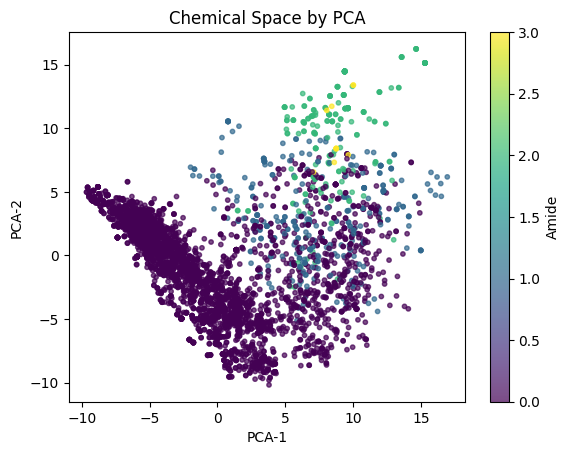

"\nscatter = plt.scatter(df_UMAP['UMAP1'], df_UMAP['UMAP2'], c=df_UMAP[color_variable], cmap='viridis', s=10, alpha=0.7)\nplt.xlabel('UMAP-1')\nplt.ylabel('UMAP-2')\nplt.title('Chemical Space by UMAP')\nplt.colorbar(scatter, label=color_variable)\nplt.savefig(f'cmnpd_umap_{color_variable}.png', dpi=400, bbox_inches='tight')\nplt.show()\n"

In [33]:
# Play with colors
import pandas as pd
import matplotlib.pyplot as plt

#df_PCA = pd.read_csv('vinafrags_pca_out.csv') #Input PCA table
df_UMAP = pd.read_csv('vinafrags_umap_output.csv') #input UMAP table

color_variable = 'Amide' #specify the color variable

scatter = plt.scatter(df_PCA['PC1'], df_PCA['PC2'], c=df_PCA[color_variable], cmap='viridis', s=10, alpha=0.7)
plt.xlabel('PCA-1')
plt.ylabel('PCA-2')
plt.title('Chemical Space by PCA')
plt.colorbar(scatter, label=color_variable)
plt.savefig(f'vinafrags_pca_{color_variable}.png', dpi=400, bbox_inches='tight')
plt.show()
"""
scatter = plt.scatter(df_UMAP['UMAP1'], df_UMAP['UMAP2'], c=df_UMAP[color_variable], cmap='viridis', s=10, alpha=0.7)
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.title('Chemical Space by UMAP')
plt.colorbar(scatter, label=color_variable)
plt.savefig(f'cmnpd_umap_{color_variable}.png', dpi=400, bbox_inches='tight')
plt.show()
"""

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load PCA and UMAP coordinates (example column names: 'MolecularID', 'PC1', 'PC2', 'UMAP1', 'UMAP2')
pca_df = pd.read_csv('frag_physchem_pca_output.csv')       # columns: e.g., 'MolecularID', 'PC1', 'PC2'
umap_df = pd.read_csv('frag_physchem_umap_output.csv')     # columns: e.g., 'MolecularID', 'UMAP1', 'UMAP2'
groups_df = pd.read_csv('top10Frags.csv')        # columns: 'MolecularID', 'Group'

# Merge group information
pca_df = pca_df.merge(groups_df, on='MolecularID', how='left')
umap_df = umap_df.merge(groups_df, on='MolecularID', how='left')

# User defines color mapping for each group
color_dict = {
    'GroupA': 'red', 'GroupB': 'blue', 'GroupC': 'green', 'GroupD': 'orange',
    'GroupE': 'purple', 'GroupF': 'brown', 'GroupG': 'pink', 'GroupH': 'gray',
    'GroupI': 'olive', 'GroupJ': 'navy'
}

# Plot PCA with groups
plt.figure(figsize=(8, 6))
for group, color in color_dict.items():
    idx = pca_df['Group'] == group
    plt.scatter(pca_df.loc[idx, 'PC1'], pca_df.loc[idx, 'PC2'], label=group, c=color, s=60, alpha=0.8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.title('PCA with Highlighted Molecule Groups')
plt.tight_layout()
plt.savefig('PCA_highlighted_groups.png', dpi=300)
plt.show()

# Plot UMAP with groups
plt.figure(figsize=(8, 6))
for group, color in color_dict.items():
    idx = umap_df['Group'] == group
    plt.scatter(umap_df.loc[idx, 'UMAP1'], umap_df.loc[idx, 'UMAP2'], label=group, c=color, s=60, alpha=0.8)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend()
plt.title('UMAP with Highlighted Molecule Groups')
plt.tight_layout()
plt.savefig('UMAP_highlighted_groups.png', dpi=300)
plt.show()


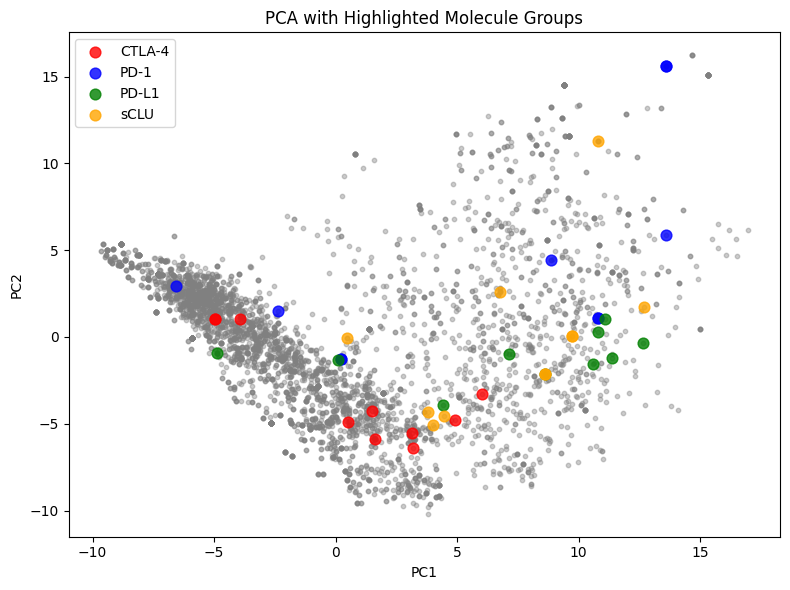

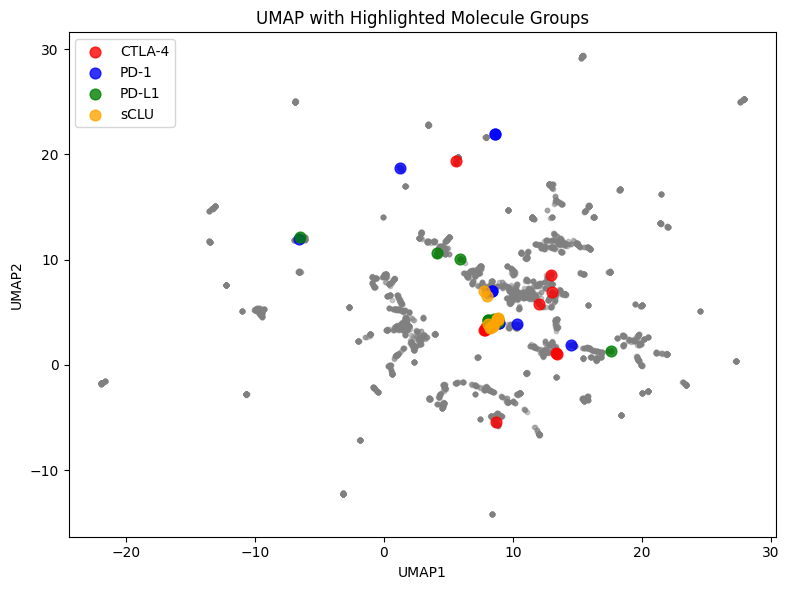

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Load PCA and UMAP coordinates (example column names: 'MolecularID', 'PC1', 'PC2', 'UMAP1', 'UMAP2')
pca_df = pd.read_csv('frag_pca_out.csv')       # columns: e.g., 'MolecularID', 'PC1', 'PC2'
umap_df = pd.read_csv('frag_umap_out.csv')     # columns: e.g., 'MolecularID', 'UMAP1', 'UMAP2'
groups_df = pd.read_csv('top10frags_ID.csv')        # columns: 'MolecularID', 'Group'

# Merge group information
pca_df = pca_df.merge(groups_df, on='MolecularID', how='left')
umap_df = umap_df.merge(groups_df, on='MolecularID', how='left')

# User defines color mapping for each group
color_dict = {
    'CTLA-4': 'red', 'PD-1': 'blue', 'PD-L1': 'green', 'sCLU': 'orange'
}

# Plot PCA with groups
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=10, alpha=0.4, c='gray')
for group, color in color_dict.items():
    idx = pca_df['Receptor'] == group
    plt.scatter(pca_df.loc[idx, 'PC1'], pca_df.loc[idx, 'PC2'], label=group, c=color, s=60, alpha=0.8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.title('PCA with Highlighted Molecule Groups')
plt.tight_layout()
plt.savefig('PCA_highlighted_groups.png', dpi=300)
plt.show()

# Plot UMAP with groups
plt.figure(figsize=(8, 6))
plt.scatter(umap_df['UMAP1'], umap_df['UMAP2'], s=10, alpha=0.4, c='gray')
for group, color in color_dict.items():
    idx = umap_df['Receptor'] == group
    plt.scatter(umap_df.loc[idx, 'UMAP1'], umap_df.loc[idx, 'UMAP2'], label=group, c=color, s=60, alpha=0.8)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend()
plt.title('UMAP with Highlighted Molecule Groups')
plt.tight_layout()
plt.savefig('UMAP_highlighted_groups.png', dpi=300)
plt.show()


## Graphical analyses of chemical space data